# Notebook Conclusion

This notebook performed a comprehensive exploratory data analysis (EDA) to investigate the spatial and temporal characteristics of NYC Yellow Taxi pickup demand with the objective of understanding demand behavior before identifying and visualizing high-demand pickup hotspots.

The analysis began by loading the processed dataset generated during the data preparation stage. The dataset consisted of taxi pickup records enriched with official NYC Taxi Zone information and engineered temporal features, including pickup hour, day of the week, month, and weekend indicators. Initial data quality assessment confirmed that the dataset was suitable for hotspot analysis after handling missing values and ensuring that all observations were associated with valid taxi zones.

Several exploratory analyses were then conducted to understand how pickup demand varies across different geographic regions and time periods.

### Borough-Level Demand Analysis

The first stage of the analysis focused on understanding the distribution of pickup demand across NYC boroughs. The results revealed a highly uneven spatial distribution of taxi activity.

- **Manhattan** emerged as the dominant borough, accounting for approximately **3.2 million pickups**, representing the majority of total taxi demand.
- **Queens** recorded approximately **350 thousand pickups**, making it the second-largest contributor to taxi activity.
- **Brooklyn** exhibited moderate demand with approximately **150 thousand pickups**.
- **Bronx**, **Staten Island**, and **EWR** contributed only a small proportion of total pickups.

These findings indicate that taxi demand is strongly concentrated in Manhattan, likely driven by business districts, tourism, commercial activities, and high commuter density. The elevated demand observed in Queens can be attributed to major transportation hubs such as JFK Airport and LaGuardia Airport.

### Pickup Zone Analysis

To identify more granular demand patterns, pickup activity was analyzed at the taxi zone level. The analysis identified several zones that consistently experienced high pickup volumes.

The top pickup zones included:

- Upper East Side South
- Upper East Side North
- JFK Airport
- Midtown Center
- Penn Station/Madison Square West
- Lincoln Square East
- Midtown East
- Times Square/Theatre District
- East Village
- Upper West Side South

These zones are characterized by dense commercial activity, tourism, residential concentration, entertainment venues, and transportation infrastructure. The presence of major airports and transit hubs among the highest-demand zones further highlights the relationship between urban mobility patterns and taxi demand.

The findings suggest that pickup hotspots are concentrated around economically and socially active areas rather than being uniformly distributed throughout the city.

### Hourly Demand Analysis

The temporal analysis investigated how taxi demand changes throughout the day.

The results demonstrated a clear daily demand cycle:

- The **lowest pickup activity** occurred during early morning hours, particularly between **3:00 AM and 5:00 AM**, where pickup counts reached their minimum.
- Demand began increasing rapidly after **6:00 AM**, corresponding to the start of commuting hours.
- Pickup activity continued to rise throughout the day.
- The **highest demand** was observed during the **evening period**, particularly between **5:00 PM and 7:00 PM**.
- Peak pickup demand occurred at approximately **6:00 PM**, with nearly **266 thousand pickups** recorded during that hour.
- Following the evening peak, demand gradually declined during late-night hours.

These patterns indicate that taxi demand is influenced by both work-related commuting and non-work-related activities, including shopping, dining, entertainment, and social engagements. The higher evening demand compared with morning demand suggests that taxi usage extends beyond traditional commuting behavior.

### Spatial–Temporal Demand Analysis

To better understand how demand patterns evolve over time across different regions, borough-level heatmaps were generated using pickup counts aggregated by hour.

The heatmap analysis revealed several important findings:

- Manhattan maintained consistently high pickup demand throughout the day.
- Demand intensity in Manhattan increased substantially during afternoon and evening periods.
- Peak Manhattan activity occurred between **5:00 PM and 6:00 PM**.
- Queens exhibited moderate and relatively stable demand patterns across most hours, potentially reflecting airport-related transportation demand.
- Brooklyn demonstrated moderate demand with less pronounced fluctuations compared with Manhattan.
- Bronx and Staten Island maintained consistently low demand levels throughout the day.

These observations indicate that pickup hotspots are dynamic rather than static. Although Manhattan consistently functions as the primary hotspot region, the intensity of demand varies considerably throughout the day. This highlights the importance of incorporating both geographic and temporal dimensions when identifying and visualizing pickup hotspots.

### Key Findings from the Exploratory Analysis

The EDA produced several important insights regarding NYC taxi pickup behavior:

- Taxi demand is highly concentrated geographically, with Manhattan serving as the dominant service region.
- Pickup activity is not uniformly distributed across taxi zones, with a limited number of zones accounting for a substantial proportion of total demand.
- Airport locations and major transportation hubs contribute significantly to overall pickup activity.
- Taxi demand exhibits strong temporal variability characterized by identifiable low-demand and peak-demand periods.
- Evening hours represent the highest-demand period for taxi services.
- The intensity of pickup hotspots changes throughout the day, emphasizing the importance of spatial-temporal analysis.
- Human mobility patterns, commuting behavior, tourism, and urban infrastructure strongly influence taxi demand dynamics.

### Analyses Performed in this Notebook

The following exploratory analyses were completed:

1. Dataset overview and quality assessment.
2. Validation of processed spatial and temporal features.
3. Borough-level pickup demand analysis.
4. Identification of top pickup zones based on demand volume.
5. Hourly pickup demand trend analysis.
6. Weekday and weekend demand comparisons.
7. Spatial-temporal heatmap analysis of borough demand across different hours.
8. Extraction of business insights related to fleet allocation and hotspot identification.

### Overall Conclusion

The exploratory data analysis successfully characterized the spatial and temporal structure of NYC taxi pickup demand. The results demonstrated that pickup demand is influenced by both location-specific factors and time-dependent travel behavior. Manhattan emerged as the dominant pickup region, while several Midtown, Upper East Side, and airport zones consistently functioned as high-demand areas.

Furthermore, demand patterns varied substantially throughout the day, with evening periods experiencing the greatest taxi utilization. The combined spatial-temporal analysis confirmed that hotspot intensity changes dynamically over time, reinforcing the need for time-aware hotspot detection approaches.

Overall, this notebook established a strong analytical foundation for the subsequent hotspot detection and visualization phase. The insights generated through EDA provide valuable guidance for identifying high-demand pickup locations and can support operational decision-making related to fleet allocation, resource optimization, demand forecasting, and improved transportation service planning within New York City's taxi ecosystem.

# Use Case 3: Detect and Visualize High-Demand Pickup Hotspots

# Notebook 2: Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore pickup demand patterns across New York City taxi zones before hotspot identification and visualization.

The analysis focuses on answering the following questions:

- How are taxi pickups distributed across NYC?
- Which taxi zones experience the highest demand?
- Which boroughs contribute most to pickup activity?
- How does pickup demand vary by time?
- Are there noticeable weekday versus weekend patterns?
- What operational insights can be derived from pickup behavior?

Understanding these patterns provides a strong foundation for identifying and visualizing high-demand pickup hotspots.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

## Load Processed Dataset

Load the cleaned dataset generated during the data preparation stage.

In [4]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE3_Pickup_hotspot_Detection/data/processed_pickup_hotspot_data.parquet"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (3718959, 10)


,tpep_pickup_datetime,PULocationID,LocationID,Borough,Zone,service_zone,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
0,2026-01-01 00:54:04,239,239,Manhattan,Upper West Side South,Yellow Zone,0,Thursday,1,0
1,2026-01-01 00:34:04,163,163,Manhattan,Midtown North,Yellow Zone,0,Thursday,1,0
2,2026-01-01 00:57:06,43,43,Manhattan,Central Park,Yellow Zone,0,Thursday,1,0
3,2026-01-01 00:15:22,142,142,Manhattan,Lincoln Square East,Yellow Zone,0,Thursday,1,0
4,2026-01-01 00:27:13,88,88,Manhattan,Financial District South,Yellow Zone,0,Thursday,1,0


## Dataset Overview

Examine the dataset structure, variable types, and overall completeness to ensure readiness for exploratory analysis.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3718959 entries, 0 to 3718958
Data columns (total 10 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tpep_pickup_datetime  datetime64[us]
 1   PULocationID          int32         
 2   LocationID            int64         
 3   Borough               object        
 4   Zone                  object        
 5   service_zone          object        
 6   pickup_hour           int32         
 7   pickup_dayofweek      object        
 8   pickup_month          int32         
 9   is_weekend            int64         
dtypes: datetime64[us](1), int32(3), int64(2), object(4)
memory usage: 241.2+ MB


In [6]:
df.describe(
    include="all"
).T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
tpep_pickup_datetime,3718959,NaN,NaN,NaN,2026-01-17 01:46:12.836785,2025-12-31 23:57:29,2026-01-09 17:52:59,2026-01-16 21:22:13,2026-01-24 07:26:30.500000,2026-02-01 00:45:01,NaN
PULocationID,3718959.0,NaN,NaN,NaN,161.273237,1.0,114.0,161.0,233.0,263.0,66.99412
LocationID,3718959.0,NaN,NaN,NaN,161.273237,1.0,114.0,161.0,233.0,263.0,66.99412
Borough,3718959,6,Manhattan,3180607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zone,3718959,259,Upper East Side South,160343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_zone,3718959,4,Yellow Zone,3047909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_hour,3718959.0,NaN,NaN,NaN,14.114554,0.0,10.0,15.0,19.0,23.0,5.985223
pickup_dayofweek,3718959,7,Saturday,671142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_month,3718959.0,NaN,NaN,NaN,1.000018,1.0,1.0,1.0,1.0,12.0,0.013982
is_weekend,3718959.0,NaN,NaN,NaN,0.280748,0.0,0.0,0.0,1.0,1.0,0.449365


## Pickup Demand by Borough

Analyze the distribution of pickups across NYC boroughs.

Understanding borough-level demand provides high-level insight into areas with the greatest taxi service utilization.

In [7]:
borough_demand = (
    df["Borough"]
    .value_counts()
    .reset_index()
)

borough_demand.columns = [
    "Borough",
    "Pickup_Count"
]

borough_demand

,Borough,Pickup_Count
0,Manhattan,3180607
1,Queens,344826
2,Brooklyn,155668
3,Bronx,36886
4,Staten Island,486
5,EWR,486


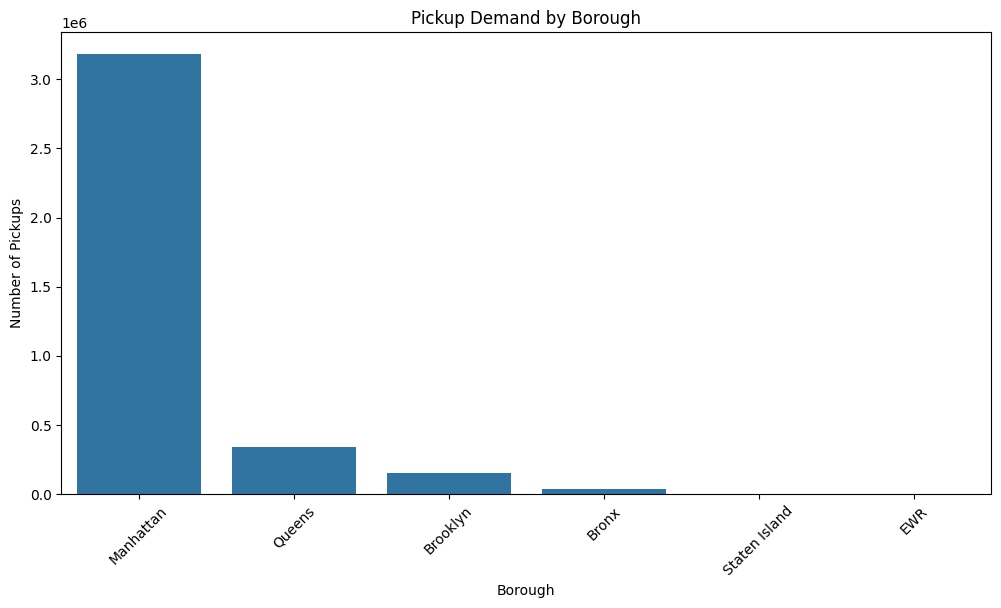

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=borough_demand,
    x="Borough",
    y="Pickup_Count"
)

plt.title(
    "Pickup Demand by Borough"
)

plt.xlabel("Borough")

plt.ylabel(
    "Number of Pickups"
)

plt.xticks(rotation=45)

plt.show()

1. Pickup Demand by Borough
Observations
Manhattan accounted for approximately 3.2 million pickups, making it the dominant borough in terms of taxi demand.
Queens recorded approximately 350 thousand pickups, emerging as the second-highest contributor.
Brooklyn exhibited moderate taxi demand with approximately 150 thousand pickups.
Bronx generated relatively low demand, contributing approximately 40 thousand pickups.
Staten Island and EWR (Newark Airport region) showed minimal pickup activity compared to other boroughs.
Insights
Taxi demand across New York City is highly concentrated within Manhattan, indicating that commercial activities, tourism, business districts, and high population density significantly influence taxi utilization.
The substantial demand observed in Queens may be attributed to major transportation hubs such as JFK Airport and LaGuardia Airport.
The large disparity between Manhattan and other boroughs suggests that taxi demand is not uniformly distributed across the city.
Business Implications
Fleet allocation strategies should prioritize Manhattan, as it represents the primary demand center.
Secondary resource allocation should focus on Queens, particularly near airport zones and major transit corridors.

# Key Insights

- Manhattan contributes the largest share of taxi pickups, indicating concentrated demand in commercial and tourist areas.

- Several taxi zones consistently appear among the top pickup locations, suggesting persistent demand hotspots.

- Pickup demand exhibits clear temporal patterns, with identifiable peak hours during the day.

- Demand distribution varies across weekdays and weekends, reflecting changing travel behavior.

- Borough-level heatmaps reveal distinct operational patterns that can inform driver allocation and service optimization.

These findings provide a strong basis for hotspot visualization and demand management strategies.

## Top Pickup Zones

Identify taxi zones with the highest pickup activity.

These zones represent potential high-demand hotspots requiring operational attention.

In [10]:
top_zones = (
    df["Zone"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_zones.columns = [
    "Zone",
    "Pickup_Count"
]

top_zones

,Zone,Pickup_Count
0,Upper East Side South,160343
1,Upper East Side North,153640
2,JFK Airport,152589
3,Midtown Center,146641
4,Penn Station/Madison Sq West,110700
5,Lincoln Square East,110004
6,Midtown East,108703
7,Times Sq/Theatre District,106114
8,East Village,100998
9,Upper West Side South,97465


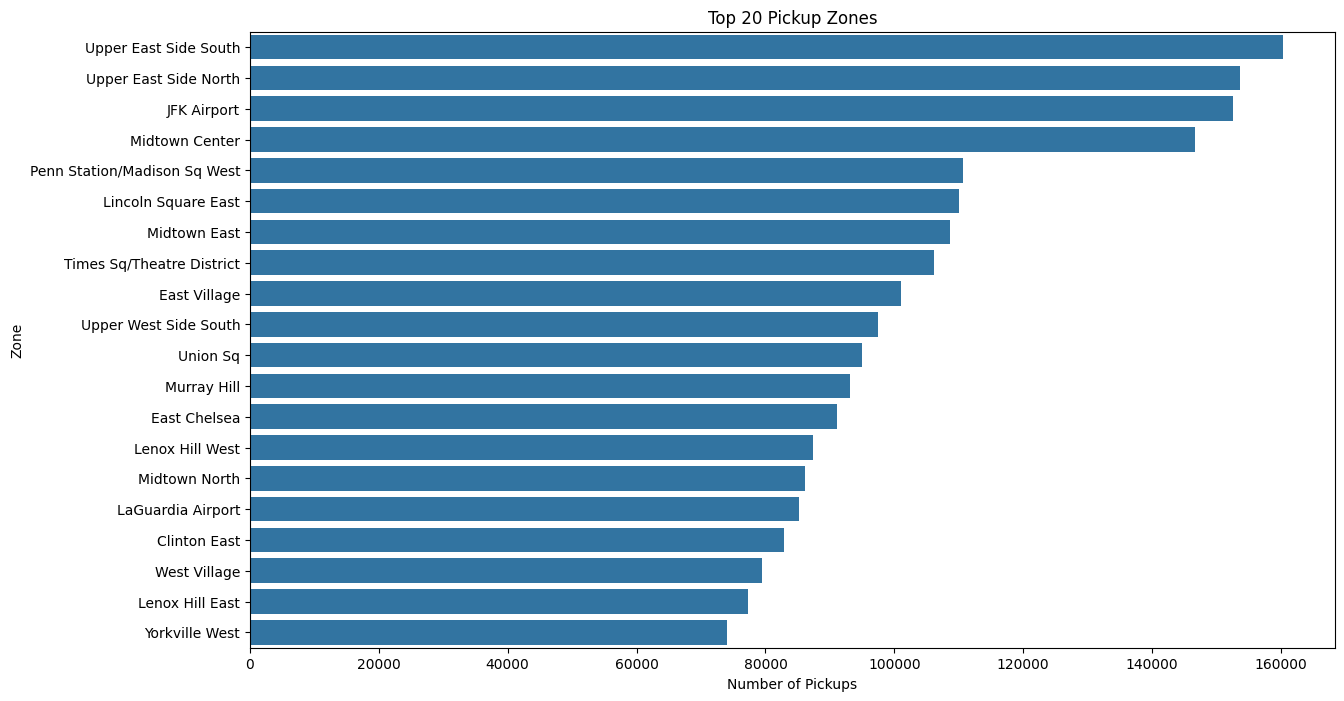

In [11]:
plt.figure(figsize=(14,8))

sns.barplot(
    data=top_zones,
    y="Zone",
    x="Pickup_Count"
)

plt.title(
    "Top 20 Pickup Zones"
)

plt.xlabel(
    "Number of Pickups"
)

plt.ylabel("Zone")

plt.show()

2. Top 20 Pickup Zones
Observations

The highest-demand pickup zones identified were:

Rank	Zone	Approximate Pickup Count
1	Upper East Side South	~160,000
2	Upper East Side North	~154,000
3	JFK Airport	~152,000
4	Midtown Center	~147,000
5	Penn Station/Madison Sq West	~112,000
6	Lincoln Square East	~110,000
7	Midtown East	~108,000
8	Times Sq/Theatre District	~106,000
9	East Village	~101,000
10	Upper West Side South	~97,000
Insights
The Upper East Side regions consistently demonstrated the highest pickup volumes.
JFK Airport ranked among the top demand zones, emphasizing the significance of airport-related transportation services.
Several Midtown Manhattan zones appeared repeatedly among the highest-demand locations, highlighting their importance as business, tourism, and transportation centers.
Business Implications
These zones represent persistent pickup hotspots where proactive driver positioning could improve service efficiency.
Demand forecasting and dynamic driver allocation should prioritize these high-demand areas.

## Pickup Demand by Hour

Analyze hourly pickup demand patterns to identify peak operational periods.

In [12]:
hourly_demand = (
    df["pickup_hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hourly_demand.columns = [
    "Hour",
    "Pickup_Count"
]

hourly_demand

,Hour,Pickup_Count
0,0,111709
1,1,77697
2,2,54003
3,3,38574
4,4,28599
5,5,32833
6,6,63590
7,7,113234
8,8,147965
9,9,156605


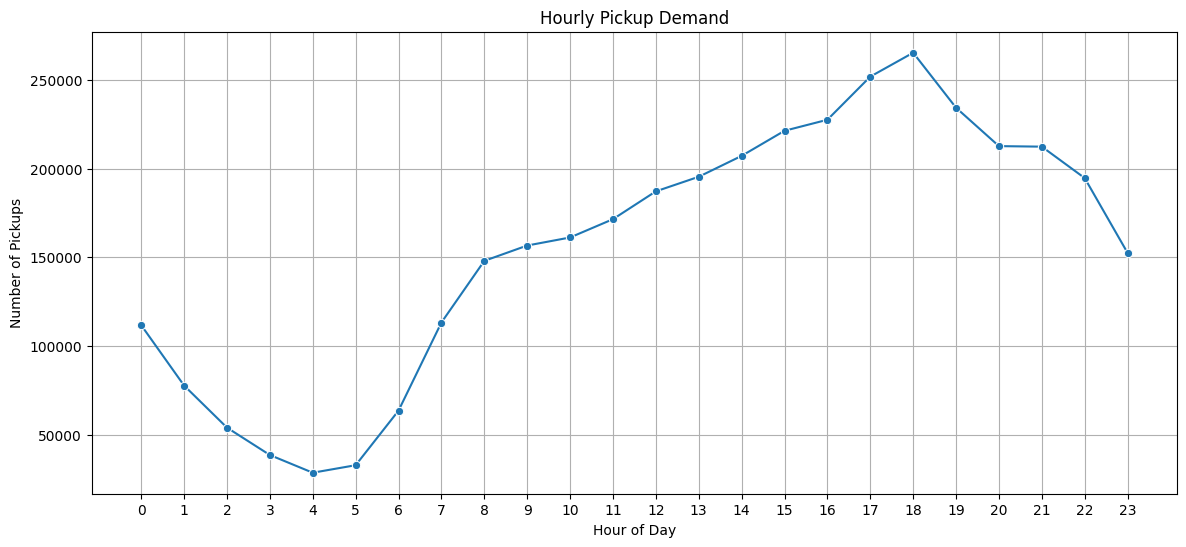

In [13]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=hourly_demand,
    x="Hour",
    y="Pickup_Count",
    marker="o"
)

plt.title(
    "Hourly Pickup Demand"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Number of Pickups"
)

plt.xticks(range(24))

plt.grid()

plt.show()

3. Hourly Pickup Demand Analysis
Observations
Early Morning Demand (Low Activity)
Hour	Approximate Pickups
04:00 AM	~28,000
05:00 AM	~33,000

Demand reached its lowest levels during early morning hours.

Morning Demand Increase
Hour	Approximate Pickups
06:00 AM	~64,000
07:00 AM	~112,000
08:00 AM	~148,000

Demand began increasing sharply after 06:00 AM.

Evening Peak Demand
Hour	Approximate Pickups
05:00 PM	~251,000
06:00 PM	~266,000
07:00 PM	~234,000

The highest pickup activity occurred during 06:00 PM, representing the peak operational period.

Late Evening Decline
Hour	Approximate Pickups
10:00 PM	~195,000
11:00 PM	~152,000

Demand gradually declined following the evening peak period.

Insights
Pickup demand exhibited a strong daily cyclical pattern.
The lowest activity was observed between 03:00 AM and 05:00 AM.
Demand increased steadily throughout the morning and afternoon periods.
The most significant demand occurred during evening commuting hours (05:00 PM – 07:00 PM).
Evening demand exceeded morning demand, suggesting additional influence from leisure, entertainment, and social activities.
Business Implications
Driver availability should be maximized during evening peak periods to reduce passenger waiting times.
Early morning periods may require fewer active drivers due to substantially lower demand.

## Pickup Demand by Day of Week

Evaluate how pickup activity changes throughout the week.

In [14]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_demand = (
    df[
        "pickup_dayofweek"
    ]
    .value_counts()
    .reindex(days_order)
    .reset_index()
)

daily_demand.columns = [
    "Day",
    "Pickup_Count"
]

daily_demand

,Day,Pickup_Count
0,Monday,378771
1,Tuesday,482567
2,Wednesday,504962
3,Thursday,654312
4,Friday,654258
5,Saturday,671142
6,Sunday,372947


## Weekend vs Weekday Demand

Compare pickup activity between weekdays and weekends.

In [15]:
weekend_demand = (
    df["is_weekend"]
    .value_counts()
    .reset_index()
)

weekend_demand.columns = [
    "Weekend",
    "Pickup_Count"
]

weekend_demand[
    "Weekend"
] = (
    weekend_demand[
        "Weekend"
    ]
    .map(
        {
            0: "Weekday",
            1: "Weekend"
        }
    )
)

weekend_demand

,Weekend,Pickup_Count
0,Weekday,2674870
1,Weekend,1044089


## Borough-Hour Demand Heatmap

Analyze hourly demand variation across boroughs to identify temporal hotspot patterns.

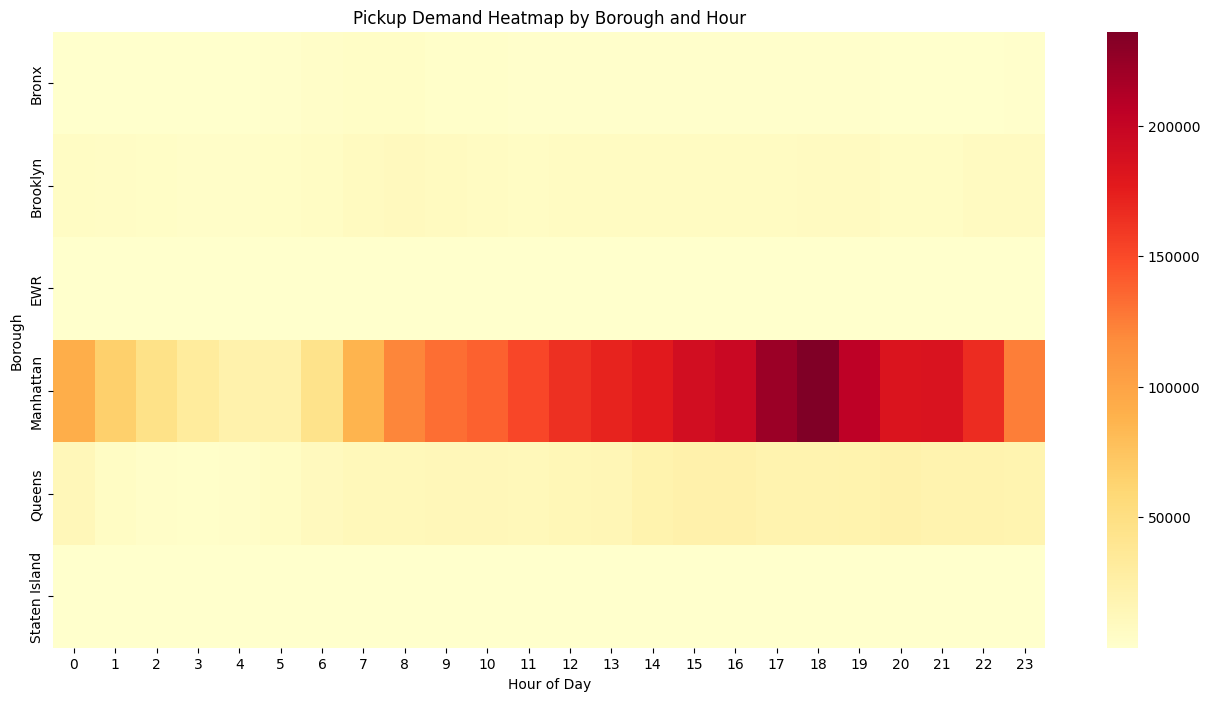

In [16]:
heatmap_data = pd.crosstab(
    df["Borough"],
    df["pickup_hour"]
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd"
)

plt.title(
    "Pickup Demand Heatmap by Borough and Hour"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Borough"
)

plt.show()

4. Borough and Hour Demand Heatmap
Observations
Manhattan
Consistently exhibited the highest pickup demand throughout the day.
Demand intensified significantly after 08:00 AM.
Peak activity occurred between 05:00 PM and 06:00 PM.
Elevated demand persisted into late evening hours.
Queens
Demonstrated moderate but relatively stable pickup demand.
Demand fluctuations were less pronounced compared to Manhattan.
Airport-related activity likely contributed to sustained demand levels.
Brooklyn
Displayed moderate pickup activity with slight increases during daytime hours.
Temporal variation was less significant than Manhattan.
Bronx and Staten Island
Maintained consistently low demand across all hours.
No distinct temporal peaks were observed.
Insights
Manhattan serves as the dominant spatial hotspot across nearly all time periods.
The intensity of hotspots varies throughout the day, indicating that demand is influenced by both location and time.
Borough-specific demand patterns suggest differing transportation behaviors and operational requirements.
Business Implications
Effective fleet management should incorporate spatial-temporal demand patterns rather than relying solely on geographic hotspots.
Dynamic driver allocation based on time-dependent demand variations could improve operational efficiency.